# Supervised

In [1]:
from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd
import mlflow

# Ensure project root is in path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.features.supervised_features import build_raw_supervised_features
from src.evaluation.supervised_validation import (
    make_stratified_folds,
    evaluate_fold_predictions
)
from src.utils.io import load_raw_data

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "supervised"
MLFLOW_TRACKING_DIR = OUTPUT_DIR / "mlruns"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(MLFLOW_TRACKING_DIR.as_uri())
mlflow.set_experiment("supervised_fraud_modeling")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")



/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/mlflow/utils/autologging_utils/versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
2026/06/27 02:24:12 INFO mlflow.tracking.fluent: Experiment with name 'supervised_fraud_modeling' does not exist. Creating a new experiment.


MLflow tracking URI: file:///Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/mlruns


### Chạy UI  MLFlow
```bash
run mlflow ui \
  --backend-store-uri outputs/supervised/mlruns \
  --host 127.0.0.1 \
  --port 5050
```

->  URL: http://127.0.0.1:5050

In [ ]:
print("Building raw features on the fly...")
raw_data = load_raw_data(DATA_DIR)
features_df = build_raw_supervised_features(
    customer_df=raw_data["dts_train"],
    sim_events=raw_data["sim_events"],
    device_sessions=raw_data["device_sessions"],
    kyc_records=raw_data["kyc_records"],
    device_catalog=raw_data["device_catalog"],
)

# Load target labels and align
dts_train_labels = pd.read_csv(DATA_DIR / "dts_train.csv")
merged = dts_train_labels[["CustomerID", "FraudFlag"]].merge(features_df, on="CustomerID", how="inner")

X = merged.drop(columns=["FraudFlag"])
y = merged["FraudFlag"]

Building raw features on the fly...


In [3]:
# Create Stratified 5-Fold splits based on FraudFlag
folds = make_stratified_folds(X, y, n_splits=5, random_state=42)
print(f"Created {len(folds)} stratified folds.")

for i, (train_idx, val_idx) in enumerate(folds):
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    print(f"Fold {i+1}:")
    print(f"  Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    print(f"  Train Fraud Rate: {y_train.mean():.4%}")
    print(f"  Val Fraud Rate: {y_val.mean():.4%}")

Created 5 stratified folds.
Fold 1:
  Train size: 40837, Val size: 10210
  Train Fraud Rate: 3.1981%
  Val Fraud Rate: 3.2027%
Fold 2:
  Train size: 40837, Val size: 10210
  Train Fraud Rate: 3.1981%
  Val Fraud Rate: 3.2027%
Fold 3:
  Train size: 40838, Val size: 10209
  Train Fraud Rate: 3.2005%
  Val Fraud Rate: 3.1933%
Fold 4:
  Train size: 40838, Val size: 10209
  Train Fraud Rate: 3.2005%
  Val Fraud Rate: 3.1933%
Fold 5:
  Train size: 40838, Val size: 10209
  Train Fraud Rate: 3.1980%
  Val Fraud Rate: 3.2031%


In [4]:
# Verify the evaluation metrics using dummy uniform predictions
np.random.seed(42)
dummy_probs = np.random.uniform(0, 1, size=len(y))

metrics = evaluate_fold_predictions(y, dummy_probs, percent=0.05)
print("Dummy Model Performance (for verification):")
print(f"  PR-AUC: {metrics['pr_auc']:.5f}")
print(f"  Recall@5%: {metrics['recall_at_5%']:.5f}")

Dummy Model Performance (for verification):
  PR-AUC: 0.03129
  Recall@5%: 0.04838


## Modeling Stage

In [ ]:
from contextlib import nullcontext

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

from src.models.supervised import (
    LGBM_AVAILABLE,
    XGB_AVAILABLE,
    create_model,
    estimate_scale_pos_weight,
    get_lr_coefficients,
)
from src.utils.woe import WOEEncoder
from src.evaluation.error_analysis import analyze_errors_by_fraud_type

NON_FEATURE_COLUMNS = ["CustomerID", "FraudFlag", "FraudType", "Churn"]


class FoldSafeModelPipeline(BaseEstimator, ClassifierMixin):

    def __init__(
        self,
        model_type,
        model_params=None,
        categorical_encoder="woe",
        scale_numeric=True,
        woe_smoothing=0.5,
        woe_min_samples=30,
    ):
        self.model_type = model_type
        self.model_params = model_params
        self.categorical_encoder = categorical_encoder
        self.scale_numeric = scale_numeric
        self.woe_smoothing = woe_smoothing
        self.woe_min_samples = woe_min_samples

    def fit(self, X, y):
        model_params = dict(self.model_params or {})
        if self.model_type == "xgb" and "scale_pos_weight" not in model_params:
            model_params["scale_pos_weight"] = estimate_scale_pos_weight(y)

        self.model_ = create_model(self.model_type, model_params)
        self.feature_cols_ = [col for col in X.columns if col not in NON_FEATURE_COLUMNS]
        X_clean = X[self.feature_cols_]

        self.numeric_cols_ = X_clean.select_dtypes(include=["number", "bool"]).columns.to_list()
        self.categorical_cols_ = X_clean.select_dtypes(exclude=["number", "bool"]).columns.to_list()

        parts = []
        if self.numeric_cols_:
            self.numeric_imputer_ = SimpleImputer(strategy="median")
            X_num = self.numeric_imputer_.fit_transform(X_clean[self.numeric_cols_])
            if self.scale_numeric:
                self.numeric_scaler_ = RobustScaler()
                X_num = self.numeric_scaler_.fit_transform(X_num)
            else:
                self.numeric_scaler_ = None
            parts.append(pd.DataFrame(X_num, columns=self.numeric_cols_, index=X.index))
        else:
            self.numeric_imputer_ = None
            self.numeric_scaler_ = None

        if self.categorical_cols_:
            if self.categorical_encoder == "woe":
                self.categorical_encoder_ = WOEEncoder(
                    event_label=1,
                    smoothing=self.woe_smoothing,
                    min_samples=self.woe_min_samples,
                )
                self.categorical_encoder_.fit(X_clean[self.categorical_cols_], y, columns=self.categorical_cols_)
                X_cat = self.categorical_encoder_.transform(X_clean[self.categorical_cols_])
                parts.append(X_cat)
            elif self.categorical_encoder == "onehot":
                self.categorical_imputer_ = SimpleImputer(strategy="most_frequent")
                X_cat_imp = self.categorical_imputer_.fit_transform(X_clean[self.categorical_cols_])
                self.categorical_encoder_ = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
                X_cat = self.categorical_encoder_.fit_transform(X_cat_imp)
                cat_cols = self.categorical_encoder_.get_feature_names_out(self.categorical_cols_)
                parts.append(pd.DataFrame(X_cat, columns=cat_cols, index=X.index))
            else:
                raise ValueError(f"Unknown categorical_encoder: {self.categorical_encoder}")
        else:
            self.categorical_encoder_ = None

        X_model = pd.concat(parts, axis=1)
        self.feature_names_ = X_model.columns.to_list()
        self.model_.fit(X_model, y)
        self.classes_ = getattr(self.model_, "classes_", np.array([0, 1]))
        return self

    def _transform_features(self, X):
        X_clean = X[self.feature_cols_]
        parts = []

        if self.numeric_cols_:
            X_num = self.numeric_imputer_.transform(X_clean[self.numeric_cols_])
            if self.numeric_scaler_ is not None:
                X_num = self.numeric_scaler_.transform(X_num)
            parts.append(pd.DataFrame(X_num, columns=self.numeric_cols_, index=X.index))

        if self.categorical_cols_:
            if self.categorical_encoder == "woe":
                parts.append(self.categorical_encoder_.transform(X_clean[self.categorical_cols_]))
            else:
                X_cat_imp = self.categorical_imputer_.transform(X_clean[self.categorical_cols_])
                X_cat = self.categorical_encoder_.transform(X_cat_imp)
                cat_cols = self.categorical_encoder_.get_feature_names_out(self.categorical_cols_)
                parts.append(pd.DataFrame(X_cat, columns=cat_cols, index=X.index))

        return pd.concat(parts, axis=1)[self.feature_names_]

    def predict_proba(self, X):
        return self.model_.predict_proba(self._transform_features(X))


def _mlflow_params_for_pipeline(pipeline):
    params = {
        "model_type": pipeline.model_type,
        "categorical_encoder": pipeline.categorical_encoder,
        "scale_numeric": pipeline.scale_numeric,
        "woe_smoothing": pipeline.woe_smoothing,
        "woe_min_samples": pipeline.woe_min_samples,
    }
    for key, value in dict(pipeline.model_params or {}).items():
        params[f"model__{key}"] = value
    return params


def run_cv_evaluation(
    X,
    y,
    pipeline,
    folds,
    model_name,
    log_to_mlflow=True,
    extra_params=None,
):
    oof_probs = np.zeros(len(y))
    fold_ids = np.zeros(len(y), dtype=int)
    fold_metrics = []

    run_context = (
        mlflow.start_run(run_name=model_name)
        if log_to_mlflow
        else nullcontext()
    )

    with run_context:
        if log_to_mlflow:
            mlflow.log_params(_mlflow_params_for_pipeline(pipeline))
            mlflow.log_params(extra_params or {})
            mlflow.log_param("n_folds", len(folds))
            mlflow.log_param("n_rows", len(X))
            mlflow.log_param("n_features_raw", X.shape[1])

        for fold_idx, (train_idx, val_idx) in enumerate(
            tqdm(folds, desc=f"{model_name} folds", unit="fold"),
            start=1,
        ):
            fold_pipeline = clone(pipeline)
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

            fold_pipeline.fit(X_train, y_train)
            probs = fold_pipeline.predict_proba(X_val)[:, 1]
            oof_probs[val_idx] = probs
            fold_ids[val_idx] = fold_idx

            metrics = evaluate_fold_predictions(y_val, probs, percent=0.05)
            fold_metrics.append(metrics)
            if log_to_mlflow:
                mlflow.log_metric("fold_pr_auc", metrics["pr_auc"], step=fold_idx)
                mlflow.log_metric("fold_recall_at_5pct", metrics["recall_at_5%"], step=fold_idx)

        mean_metrics = {
            key: float(np.mean([fold_metric[key] for fold_metric in fold_metrics]))
            for key in fold_metrics[0]
        }
        if log_to_mlflow:
            mlflow.log_metric("mean_pr_auc", mean_metrics["pr_auc"])
            mlflow.log_metric("mean_recall_at_5pct", mean_metrics["recall_at_5%"])

    customer_ids = X["CustomerID"] if "CustomerID" in X.columns else np.arange(len(y))
    oof_df = pd.DataFrame(
        {
            "CustomerID": customer_ids,
            "Fold": fold_ids,
            "y_true": y,
            "y_prob": oof_probs,
            "model_name": model_name,
        }
    )
    return oof_df, mean_metrics

### Baseline Logistic Regression

In [ ]:
lr_pipeline = FoldSafeModelPipeline(
    model_type="logistic",
    model_params={
        "C": 1.0,
        "penalty": "l2",
        "max_iter": 10000,
    },
    categorical_encoder="woe",
    scale_numeric=True,
    woe_smoothing=0.5,
    woe_min_samples=30,
)

oof_lr_df, lr_metrics = run_cv_evaluation(
    X=X,
    y=y,
    pipeline=lr_pipeline,
    folds=folds,
    model_name="logistic_regression",
)

lr_metrics


logistic_regression folds:   0%|          | 0/5 [00:00<?, ?fold/s]

/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  war

{'pr_auc': 0.69550456143499, 'recall_at_5%': 0.7171103731637304}

### Logistic Regression Coefficients

WOE hiện dùng `log(non_event / event)`, nên WOE càng âm thường là rủi ro fraud càng cao. Helper dưới đây đọc hệ số từ estimator thuần trong pipeline notebook.

In [19]:
fitted_lr = clone(lr_pipeline).fit(X, y)
coef_df = get_lr_coefficients(
    fitted_model=fitted_lr.model_,
    feature_names=fitted_lr.feature_names_,
)

coef_df.head(20)


/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Feature,Coefficient,AbsCoefficient,Interpretation
0,face_match_score,-5.658412,5.658412,Lower face_match_score increases the model fra...
1,high_shared_imei_flag,4.318827,4.318827,Higher high_shared_imei_flag increases the mod...
2,NonUSTravel_woe,3.948412,3.948412,Higher/more positive WOE means lower category ...
3,kyc_level_ord,3.946674,3.946674,Higher kyc_level_ord increases the model fraud...
4,has_iddoc_score,2.530005,2.530005,Higher has_iddoc_score increases the model fra...
5,shared_imei_flag,2.318270,2.318270,Higher shared_imei_flag increases the model fr...
6,TruckOwner_woe,-2.265658,2.265658,Lower/more negative WOE means higher category ...
7,datacenter_ratio,2.106124,2.106124,Higher datacenter_ratio increases the model fr...
8,is_generic_or_clone,-1.906749,1.906749,Lower is_generic_or_clone increases the model ...
9,tac_customer_count_max,-1.860894,1.860894,Lower tac_customer_count_max increases the mod...


### Gradient Boosting


In [8]:
gbm_pipeline = FoldSafeModelPipeline(
    model_type="gbm",
    model_params={
        "max_depth": 5,
        "learning_rate": 0.05,
        "max_iter": 100,  # HistGradientBoosting equivalent of n_estimators (supported as alias)
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
    },
    categorical_encoder="woe",
    scale_numeric=True,
    woe_smoothing=0.5,
    woe_min_samples=30,
)

oof_gbm_df, gbm_metrics = run_cv_evaluation(
    X=X,
    y=y,
    pipeline=gbm_pipeline,
    folds=folds,
    model_name="gradient_boosting",
)

gbm_metrics


gradient_boosting folds:   0%|          | 0/5 [00:00<?, ?fold/s]

{'pr_auc': 0.8024086410596251, 'recall_at_5%': 0.8107971707847883}

### Optional LightGBM / XGBoost


In [9]:
if LGBM_AVAILABLE:
    lgbm_pipeline = FoldSafeModelPipeline(
        model_type="lgbm",
        model_params={
            "n_estimators": 100,
            "learning_rate": 0.05,
            "max_depth": 5,
            "num_leaves": 31,
            "min_child_samples": 20,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.0,
            "reg_lambda": 0.0,
        },
        categorical_encoder="woe",
    )
    oof_lgbm_df, lgbm_metrics = run_cv_evaluation(X, y, lgbm_pipeline, folds, "lgbm")
    display(lgbm_metrics)
else:
    print("LightGBM unavailable. On macOS, install native OpenMP first: brew install libomp")

if XGB_AVAILABLE:
    xgb_pipeline = FoldSafeModelPipeline(
        model_type="xgb",
        model_params={
            "n_estimators": 100,
            "learning_rate": 0.05,
            "max_depth": 5,
            "min_child_weight": 1.0,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.0,
            "reg_lambda": 1.0,
        },
        categorical_encoder="woe",
    )
    oof_xgb_df, xgb_metrics = run_cv_evaluation(X, y, xgb_pipeline, folds, "xgb")
    display(xgb_metrics)
else:
    print("XGBoost unavailable. On macOS, install native OpenMP first: brew install libomp")


lgbm folds:   0%|          | 0/5 [00:00<?, ?fold/s]

{'pr_auc': 0.8027247098475433, 'recall_at_5%': 0.8095833098816158}

xgb folds:   0%|          | 0/5 [00:00<?, ?fold/s]

{'pr_auc': 0.8028522687225083, 'recall_at_5%': 0.8163036340781599}

### Optuna Tuning


In [10]:
try:
    import optuna
except ImportError:
    optuna = None


N_OPTUNA_TRIALS = 15


def _suggest_pipeline_params(trial, model_type):
    if model_type == "logistic":
        c = trial.suggest_float("C", 0.01, 10.0, log=True)
        model_params = {
            "C": c,
            "penalty": "l2",
            "max_iter": 1000,
        }
        scale_numeric = True
    elif model_type == "gbm":
        model_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_iter": trial.suggest_int("max_iter", 30, 160),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 120),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 10.0, log=True),
        }
        scale_numeric = trial.suggest_categorical("scale_numeric", [False, True])
    elif model_type == "lgbm":
        model_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 30, 180),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 120),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        }
        scale_numeric = trial.suggest_categorical("scale_numeric", [False, True])
    elif model_type == "xgb":
        model_params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 30, 180),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        }
        scale_numeric = trial.suggest_categorical("scale_numeric", [False, True])
    else:
        raise ValueError(f"Unsupported tuning model type: {model_type}")

    pipeline_params = {
        "model_type": model_type,
        "model_params": model_params,
        "categorical_encoder": "woe",
        "scale_numeric": scale_numeric,
        "woe_min_samples": trial.suggest_int("woe_min_samples", 30, 160),
        "woe_smoothing": trial.suggest_float("woe_smoothing", 0.1, 2.0),
    }
    return pipeline_params


def make_pipeline_from_params(pipeline_params):
    return FoldSafeModelPipeline(**pipeline_params)


def _flatten_pipeline_params(pipeline_params):
    flat_params = {
        "model_type": pipeline_params["model_type"],
        "categorical_encoder": pipeline_params["categorical_encoder"],
        "scale_numeric": pipeline_params["scale_numeric"],
        "woe_min_samples": pipeline_params["woe_min_samples"],
        "woe_smoothing": pipeline_params["woe_smoothing"],
    }
    for key, value in dict(pipeline_params.get("model_params") or {}).items():
        flat_params[f"model__{key}"] = value
    return flat_params


def best_pipeline_from_study(study, model_type):
    params = dict(study.best_params)

    class FixedTrial:
        def suggest_float(self, name, *args, **kwargs):
            return params[name]

        def suggest_int(self, name, *args, **kwargs):
            return params[name]

        def suggest_categorical(self, name, choices):
            return params[name]

    return make_pipeline_from_params(_suggest_pipeline_params(FixedTrial(), model_type))


def tune_model_with_optuna(X, y, folds, model_type="gbm", n_trials=N_OPTUNA_TRIALS, random_state=42):
    if optuna is None:
        raise ImportError("Install Optuna first: uv add optuna")

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        pipeline_params = _suggest_pipeline_params(trial, model_type)
        pipeline = make_pipeline_from_params(pipeline_params)
        with mlflow.start_run(run_name=f"{model_type}_trial_{trial.number}", nested=True):
            mlflow.set_tags({
                "stage": "optuna_trial",
                "model_type": model_type,
                "optimizer": "optuna",
            })
            mlflow.log_param("trial_number", trial.number)
            mlflow.log_params(_flatten_pipeline_params(pipeline_params))
            _, metrics = run_cv_evaluation(
                X, y, pipeline, folds, model_name=f"{model_type}_trial", log_to_mlflow=False
            )
            mlflow.log_metric("pr_auc", metrics["pr_auc"])
            mlflow.log_metric("recall_at_5pct", metrics["recall_at_5%"])
            return metrics["pr_auc"]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state),
    )
    with mlflow.start_run(run_name=f"optuna_{model_type}"):
        mlflow.set_tags({
            "stage": "optuna_study",
            "model_type": model_type,
            "optimizer": "optuna",
        })
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("objective_metric", "pr_auc")
        mlflow.log_param("random_state", random_state)
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        mlflow.log_metric("best_pr_auc", study.best_value)
        mlflow.log_params({f"best__{key}": value for key, value in study.best_params.items()})
    return study


logistic_study = tune_model_with_optuna(X, y, folds, model_type="logistic", n_trials=N_OPTUNA_TRIALS)
print("logistic", logistic_study.best_params, logistic_study.best_value)

lr_pipeline_tuned = best_pipeline_from_study(logistic_study, "logistic")
oof_lr_tuned_df, lr_tuned_metrics = run_cv_evaluation(
    X, y, lr_pipeline_tuned, folds, "logistic_regression_tuned"
)
display(lr_tuned_metrics)

gbm_study = tune_model_with_optuna(X, y, folds, model_type="gbm", n_trials=N_OPTUNA_TRIALS)
print("gbm", gbm_study.best_params, gbm_study.best_value)

gbm_pipeline_tuned = best_pipeline_from_study(gbm_study, "gbm")
oof_gbm_tuned_df, gbm_tuned_metrics = run_cv_evaluation(
    X, y, gbm_pipeline_tuned, folds, "gradient_boosting_tuned"
)
display(gbm_tuned_metrics)

if LGBM_AVAILABLE:
    lgbm_study = tune_model_with_optuna(X, y, folds, model_type="lgbm", n_trials=N_OPTUNA_TRIALS)
    print("lgbm", lgbm_study.best_params, lgbm_study.best_value)

    lgbm_pipeline_tuned = best_pipeline_from_study(lgbm_study, "lgbm")
    oof_lgbm_tuned_df, lgbm_tuned_metrics = run_cv_evaluation(
        X, y, lgbm_pipeline_tuned, folds, "lgbm_tuned"
    )
    display(lgbm_tuned_metrics)
else:
    lgbm_study = None
    lgbm_pipeline_tuned = None
    print("LightGBM unavailable. On macOS, install native OpenMP first: brew install libomp")

if XGB_AVAILABLE:
    xgb_study = tune_model_with_optuna(X, y, folds, model_type="xgb", n_trials=N_OPTUNA_TRIALS)
    print("xgb", xgb_study.best_params, xgb_study.best_value)

    xgb_pipeline_tuned = best_pipeline_from_study(xgb_study, "xgb")
    oof_xgb_tuned_df, xgb_tuned_metrics = run_cv_evaluation(
        X, y, xgb_pipeline_tuned, folds, "xgb_tuned"
    )
    display(xgb_tuned_metrics)
else:
    xgb_study = None
    xgb_pipeline_tuned = None
    print("XGBoost unavailable. On macOS, install native OpenMP first: brew install libomp")


  0%|          | 0/15 [00:00<?, ?it/s]

logistic_trial folds:   0%|          | 0/5 [00:00<?, ?fold/s]

/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative sol

logistic_trial folds:   0%|          | 0/5 [00:00<?, ?fold/s]

/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative sol

...

xgb_trial folds:   0%|          | 0/5 [00:00<?, ?fold/s]

xgb_trial folds:   0%|          | 0/5 [00:00<?, ?fold/s]

xgb {'learning_rate': 0.0817286751953337, 'n_estimators': 176, 'max_depth': 6, 'min_child_weight': 8.633090307988533, 'subsample': 0.7122984917310959, 'colsample_bytree': 0.6241179724286258, 'reg_alpha': 1.076665495760227, 'reg_lambda': 0.0015888893828360387, 'scale_numeric': True, 'woe_min_samples': 96, 'woe_smoothing': 1.7726118113124238} 0.815955844693012


xgb_tuned folds:   0%|          | 0/5 [00:00<?, ?fold/s]

{'pr_auc': 0.815955844693012, 'recall_at_5%': 0.824271589651226}

### Stacking Ensemble


In [21]:
def run_stacking_cv(
    X,
    y,
    folds,
    base_pipelines,
    meta_params=None,
    n_inner_splits=3,
    random_state=42,
    model_name="stacking_ensemble",
):
    from sklearn.linear_model import LogisticRegression

    oof_probs = np.zeros(len(y))
    fold_ids = np.zeros(len(y), dtype=int)
    model_names = list(base_pipelines)
    fold_metrics = []
    meta_params = dict(meta_params or {})
    meta_params.setdefault("class_weight", "balanced")
    meta_params.setdefault("random_state", random_state)
    meta_params.setdefault("max_iter", 10000)

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        inner_folds = list(
            StratifiedKFold(n_splits=n_inner_splits, shuffle=True, random_state=random_state)
            .split(X_train, y_train)
        )
        inner_oof = pd.DataFrame(0.0, index=X_train.index, columns=model_names)

        for inner_train_idx, inner_val_idx in inner_folds:
            X_itrain, y_itrain = X_train.iloc[inner_train_idx], y_train.iloc[inner_train_idx]
            X_ival = X_train.iloc[inner_val_idx]
            for name, pipeline in base_pipelines.items():
                fold_pipeline = clone(pipeline).fit(X_itrain, y_itrain)
                inner_oof.iloc[inner_val_idx, model_names.index(name)] = fold_pipeline.predict_proba(X_ival)[:, 1]

        meta_model = LogisticRegression(**meta_params)
        meta_model.fit(inner_oof, y_train)

        val_base_preds = pd.DataFrame(0.0, index=X_val.index, columns=model_names)
        for name, pipeline in base_pipelines.items():
            fitted_base = clone(pipeline).fit(X_train, y_train)
            val_base_preds[name] = fitted_base.predict_proba(X_val)[:, 1]

        probs = meta_model.predict_proba(val_base_preds)[:, 1]
        oof_probs[val_idx] = probs
        fold_ids[val_idx] = fold_idx + 1
        fold_metrics.append(evaluate_fold_predictions(y_val, probs, percent=0.05))

    metrics = {
        key: float(np.mean([fold_metric[key] for fold_metric in fold_metrics]))
        for key in fold_metrics[0]
    }
    oof_df = pd.DataFrame(
        {
            "CustomerID": X["CustomerID"],
            "Fold": fold_ids,
            "y_true": y,
            "y_prob": oof_probs,
            "model_name": model_name,
        }
    )
    return oof_df, metrics


def tune_stacking_with_optuna(
    X,
    y,
    folds,
    base_pipelines,
    n_trials=N_OPTUNA_TRIALS,
    random_state=42,
):
    if optuna is None:
        raise ImportError("Install Optuna first: uv add optuna")

    def objective(trial):
        meta_params = {
            "C": trial.suggest_float("meta_C", 0.01, 10.0, log=True),
            "penalty": "l2",
            "max_iter": 10000,
            "class_weight": "balanced",
            "random_state": random_state,
        }
        n_inner_splits = trial.suggest_int("n_inner_splits", 3, 5)
        with mlflow.start_run(run_name=f"stacking_trial_{trial.number}", nested=True):
            mlflow.set_tags({
                "stage": "optuna_trial",
                "model_type": "stacking_ensemble",
                "optimizer": "optuna",
            })
            mlflow.log_param("trial_number", trial.number)
            mlflow.log_params({f"meta__{key}": value for key, value in meta_params.items()})
            mlflow.log_param("n_inner_splits", n_inner_splits)
            mlflow.log_param("base_models", ",".join(base_pipelines))
            _, metrics = run_stacking_cv(
                X,
                y,
                folds,
                base_pipelines=base_pipelines,
                meta_params=meta_params,
                n_inner_splits=n_inner_splits,
                random_state=random_state,
                model_name="stacking_ensemble_trial",
            )
            mlflow.log_metric("pr_auc", metrics["pr_auc"])
            mlflow.log_metric("recall_at_5pct", metrics["recall_at_5%"])
            return metrics["pr_auc"]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state),
    )
    with mlflow.start_run(run_name="optuna_stacking_ensemble"):
        mlflow.set_tags({
            "stage": "optuna_study",
            "model_type": "stacking_ensemble",
            "optimizer": "optuna",
        })
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("objective_metric", "pr_auc")
        mlflow.log_param("random_state", random_state)
        mlflow.log_param("base_models", ",".join(base_pipelines))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        mlflow.log_metric("best_pr_auc", study.best_value)
        mlflow.log_params({f"best__{key}": value for key, value in study.best_params.items()})
    return study


base_pipelines = {
    "logistic": lr_pipeline_tuned,
    "gbm": gbm_pipeline_tuned,
}

optional_base_pipelines = {
    "lgbm": lgbm_pipeline_tuned,
    "xgb": xgb_pipeline_tuned,
}
base_pipelines.update(
    {name: pipeline for name, pipeline in optional_base_pipelines.items() if pipeline is not None}
)

print("Stacking base models:", list(base_pipelines))

stacking_study = tune_stacking_with_optuna(
    X, y, folds, base_pipelines, n_trials=N_OPTUNA_TRIALS
)
print("stacking", stacking_study.best_params, stacking_study.best_value)

best_stack_meta_params = {
    "C": stacking_study.best_params["meta_C"],
    "penalty": "l2",
    "max_iter": 10000,
    "class_weight": "balanced",
    "random_state": 42,
}

oof_stack_df, stack_metrics = run_stacking_cv(
    X,
    y,
    folds,
    base_pipelines=base_pipelines,
    meta_params=best_stack_meta_params,
    n_inner_splits=stacking_study.best_params["n_inner_splits"],
    model_name="stacking_ensemble_tuned",
)
stack_metrics


Stacking base models: ['logistic', 'gbm', 'lgbm', 'xgb']


  0%|          | 0/15 [00:00<?, ?it/s]

/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative sol

stacking {'meta_C': 9.1475824284567, 'n_inner_splits': 4} 0.8202542702781683


/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative sol

{'pr_auc': 0.8202542702781683, 'recall_at_5%': 0.8310087990844449}

## Error Analysis By Fraud Type


In [22]:
train_labels = pd.read_csv(DATA_DIR / "dts_train.csv")

model_outputs = [
    ("logistic_baseline", "oof_lr_df", "lr_metrics"),
    ("logistic_tuned", "oof_lr_tuned_df", "lr_tuned_metrics"),
    ("gbm_baseline", "oof_gbm_df", "gbm_metrics"),
    ("gbm_tuned", "oof_gbm_tuned_df", "gbm_tuned_metrics"),
    ("lgbm_baseline", "oof_lgbm_df", "lgbm_metrics"),
    ("lgbm_tuned", "oof_lgbm_tuned_df", "lgbm_tuned_metrics"),
    ("xgb_baseline", "oof_xgb_df", "xgb_metrics"),
    ("xgb_tuned", "oof_xgb_tuned_df", "xgb_tuned_metrics"),
    ("stacking_tuned", "oof_stack_df", "stack_metrics"),
]

available_model_rows = []
for model_name, oof_var, metrics_var in model_outputs:
    if oof_var not in globals():
        continue

    metrics = globals().get(metrics_var, {})
    if not isinstance(metrics, dict):
        metrics = {}

    available_model_rows.append(
        {
            "model_name": model_name,
            "oof_var": oof_var,
            "metrics_var": metrics_var,
            "pr_auc": metrics.get("pr_auc", np.nan),
            "recall_at_5%": metrics.get("recall_at_5%", np.nan),
        }
    )

model_summary_df = (
    pd.DataFrame(available_model_rows)
    .sort_values("pr_auc", ascending=False, na_position="last")
    .reset_index(drop=True)
)

print("Available supervised models ranked by mean 5-fold PR-AUC")
display(model_summary_df[["model_name", "pr_auc", "recall_at_5%"]])

error_analysis_by_model = {}
for row in model_summary_df.itertuples(index=False):
    error_df = analyze_errors_by_fraud_type(
        oof_df=globals()[row.oof_var],
        train_labels_df=train_labels,
        review_rate=0.05,
        include_non_fraud=False,
    )
    error_analysis_by_model[row.model_name] = error_df

    print(f"{row.model_name} fraud archetypes")
    display(error_df)

combined_error_df = pd.concat(
    [df.assign(model_name=model_name) for model_name, df in error_analysis_by_model.items()],
    ignore_index=True,
)

priority_error_df = (
    combined_error_df[combined_error_df["FraudType"].isin(["sim_swap_ato", "mule"])]
    .sort_values(["FraudType", "RecallAtReviewRate"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Priority archetype comparison: sim_swap_ato and mule")
display(priority_error_df)

best_model_name = model_summary_df.loc[0, "model_name"]
best_error_df = error_analysis_by_model[best_model_name]

print(f"Best model by mean 5-fold PR-AUC: {best_model_name}")
display(best_error_df)


Available supervised models ranked by mean 5-fold PR-AUC


,model_name,pr_auc,recall_at_5%
0,stacking_tuned,0.820254,0.831009
1,lgbm_tuned,0.816581,0.829784
2,xgb_tuned,0.815956,0.824272
3,gbm_tuned,0.808361,0.815088
4,xgb_baseline,0.802852,0.816304
5,lgbm_baseline,0.802725,0.809583
6,gbm_baseline,0.802409,0.810797
7,logistic_baseline,0.695505,0.717110
8,logistic_tuned,0.695272,0.718947


stacking_tuned fraud archetypes


,FraudType,FraudCount,CapturedFraudCount,RecallAtReviewRate,MeanScore,MeanRankPct,Priority
0,sim_swap_ato,499,389,0.779559,0.835779,0.926341,1
1,mule,429,329,0.766900,0.835418,0.939037,1
2,device_farm,382,342,0.895288,0.918378,0.962112,0
3,subscription_fraud,323,296,0.916409,0.932908,0.971339,0


lgbm_tuned fraud archetypes


...

,FraudType,FraudCount,CapturedFraudCount,RecallAtReviewRate,MeanScore,MeanRankPct,Priority
0,sim_swap_ato,499,320,0.641283,0.759011,0.901672,1
1,mule,429,284,0.662005,0.769044,0.909768,1
2,device_farm,382,323,0.845550,0.894088,0.954630,0
3,subscription_fraud,323,251,0.777090,0.856931,0.946652,0


Priority archetype comparison: sim_swap_ato and mule


,FraudType,FraudCount,CapturedFraudCount,RecallAtReviewRate,MeanScore,MeanRankPct,Priority,model_name
0,mule,429,329,0.766900,0.835418,0.939037,1,stacking_tuned
1,mule,429,329,0.766900,0.752120,0.931676,1,lgbm_tuned
2,mule,429,326,0.759907,0.693932,0.931950,1,xgb_tuned
3,mule,429,322,0.750583,0.745026,0.938188,1,xgb_baseline
4,mule,429,321,0.748252,0.752667,0.938515,1,lgbm_baseline
5,mule,429,315,0.734266,0.769420,0.938256,1,gbm_tuned
6,mule,429,314,0.731935,0.743204,0.935789,1,gbm_baseline
7,mule,429,285,0.664336,0.768319,0.909908,1,logistic_baseline
8,mule,429,284,0.662005,0.769044,0.909768,1,logistic_tuned
9,sim_swap_ato,499,391,0.783567,0.754567,0.923824,1,lgbm_tuned


Best model by mean 5-fold PR-AUC: stacking_tuned


,FraudType,FraudCount,CapturedFraudCount,RecallAtReviewRate,MeanScore,MeanRankPct,Priority
0,sim_swap_ato,499,389,0.779559,0.835779,0.926341,1
1,mule,429,329,0.766900,0.835418,0.939037,1
2,device_farm,382,342,0.895288,0.918378,0.962112,0
3,subscription_fraud,323,296,0.916409,0.932908,0.971339,0


## Model Calibration & Scoring

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from src.scorecard.calibration import fit_isotonic_calibrator, build_reliability_curve

# Configuration & Setup
BEST_MODEL_NAME_FALLBACK = "stacking_tuned"
BASE_SCORE = 600
PDO = 50

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "supervised"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_OOF_MAP = {
    "logistic_tuned": "oof_lr_tuned_df",
    "gbm_tuned": "oof_gbm_tuned_df",
    "lgbm_tuned": "oof_lgbm_tuned_df",
    "xgb_tuned": "oof_xgb_tuned_df",
    "stacking_tuned": "oof_stack_df",
}

calibration_model_names = [
    model_name
    for model_name, oof_var in FINAL_MODEL_OOF_MAP.items()
    if globals().get(oof_var) is not None
]

if not calibration_model_names:
    raise RuntimeError(
        "No OOF prediction dataframes found for calibration. "
        f"Expected one of: {list(FINAL_MODEL_OOF_MAP.values())}"
    )

if "model_summary_df" in globals() and not model_summary_df.empty:
    calibration_model_summary_df = (
        model_summary_df[model_summary_df["model_name"].isin(calibration_model_names)]
        .sort_values("pr_auc", ascending=False)
        .reset_index(drop=True)
    )
else:
    calibration_model_summary_df = pd.DataFrame({"model_name": calibration_model_names})
    calibration_model_summary_df["pr_auc"] = np.nan
    calibration_model_summary_df["recall_at_5%"] = np.nan

if calibration_model_summary_df.empty:
    raise RuntimeError(
        "OOF dataframes exist, but none of them are present in model_summary_df. "
        f"OOF candidates: {calibration_model_names}"
    )

best_model_name = calibration_model_summary_df.loc[0, "model_name"]
if pd.isna(calibration_model_summary_df.loc[0, "pr_auc"]) and BEST_MODEL_NAME_FALLBACK in calibration_model_names:
    best_model_name = BEST_MODEL_NAME_FALLBACK

print("Calibration candidates:", calibration_model_names)
print(f"Reference/best model by mean 5-fold PR-AUC: {best_model_name}")
display(calibration_model_summary_df)


Calibration candidates: ['logistic_tuned', 'gbm_tuned', 'lgbm_tuned', 'xgb_tuned', 'stacking_tuned']
Reference/best model by mean 5-fold PR-AUC: stacking_tuned


,model_name,oof_var,metrics_var,pr_auc,recall_at_5%
0,stacking_tuned,oof_stack_df,stack_metrics,0.820254,0.831009
1,lgbm_tuned,oof_lgbm_tuned_df,lgbm_tuned_metrics,0.816581,0.829784
2,xgb_tuned,oof_xgb_tuned_df,xgb_tuned_metrics,0.815956,0.824272
3,gbm_tuned,oof_gbm_tuned_df,gbm_tuned_metrics,0.808361,0.815088
4,logistic_tuned,oof_lr_tuned_df,lr_tuned_metrics,0.695272,0.718947


In [36]:
# Fit one IsotonicRegression calibrator per tuned model OOF prediction.
calibration_artifacts = {}
reliability_frames = []

for model_name in calibration_model_names:
    oof_var = FINAL_MODEL_OOF_MAP[model_name]
    oof_model_df = globals().get(oof_var)
    if oof_model_df is None:
        continue

    print(f"Fitting Isotonic Regression for {model_name} from {oof_var}...")
    raw_oof_p_model = oof_model_df["y_prob"].to_numpy()
    true_y_model = oof_model_df["y_true"].to_numpy()

    calibrator = fit_isotonic_calibrator(raw_oof_p_model, true_y_model)
    calibrated_oof_p_model = calibrator.predict(raw_oof_p_model)

    model_reliability_df = build_reliability_curve(
        true_y=true_y_model,
        raw_probs=raw_oof_p_model,
        calibrated_probs=calibrated_oof_p_model,
        bins=10,
    )
    model_reliability_df.insert(0, "model_name", model_name)
    reliability_frames.append(model_reliability_df)

    calibration_artifacts[model_name] = {
        "oof_var": oof_var,
        "oof_df": oof_model_df,
        "raw_oof_p": raw_oof_p_model,
        "true_y": true_y_model,
        "calibrator": calibrator,
        "calibrated_oof_p": calibrated_oof_p_model,
        "reliability_df": model_reliability_df,
    }

reliability_df = pd.concat(reliability_frames, ignore_index=True)

# Backward-compatible aliases for the reference/best model.
oof_df = calibration_artifacts[best_model_name]["oof_df"]
raw_oof_p = calibration_artifacts[best_model_name]["raw_oof_p"]
true_y = calibration_artifacts[best_model_name]["true_y"]
iso_reg = calibration_artifacts[best_model_name]["calibrator"]
calibrated_oof_p = calibration_artifacts[best_model_name]["calibrated_oof_p"]

print("\nReliability curve table for all calibrated models:")
display(reliability_df)

reliability_path = OUTPUT_DIR / "supervised_calibration_reliability_curve.csv"
reliability_df.to_csv(reliability_path, index=False)
print(f"File saved successfully: {reliability_path}")


Fitting Isotonic Regression for logistic_tuned from oof_lr_tuned_df...
Fitting Isotonic Regression for gbm_tuned from oof_gbm_tuned_df...
Fitting Isotonic Regression for lgbm_tuned from oof_lgbm_tuned_df...
Fitting Isotonic Regression for xgb_tuned from oof_xgb_tuned_df...
Fitting Isotonic Regression for stacking_tuned from oof_stack_df...

Reliability curve table for all calibrated models:


,model_name,Bin_Range,bin_count,mean_predicted_prob,mean_calibrated_prob,actual_fraud_rate
0,logistic_tuned,"(-0.002, 0.1]",26245,0.041258,0.002121,0.002210
1,logistic_tuned,"(0.1, 0.2]",9150,0.143097,0.005825,0.006448
2,logistic_tuned,"(0.2, 0.3]",4672,0.245680,0.010448,0.008990
3,logistic_tuned,"(0.3, 0.4]",2951,0.346747,0.018408,0.019315
4,logistic_tuned,"(0.4, 0.5]",1981,0.447149,0.023906,0.023725
5,logistic_tuned,"(0.5, 0.6]",1495,0.547980,0.032447,0.032107
6,logistic_tuned,"(0.6, 0.7]",1194,0.648272,0.055754,0.055276
7,logistic_tuned,"(0.7, 0.8]",996,0.748955,0.102242,0.103414
8,logistic_tuned,"(0.8, 0.9]",856,0.848375,0.168739,0.167056
9,logistic_tuned,"(0.9, 1.0]",1507,0.971007,0.671655,0.670206


File saved successfully: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/supervised_calibration_reliability_curve.csv


In [37]:
from sklearn.metrics import brier_score_loss

brier_rows = []
for model_name, artifact in calibration_artifacts.items():
    brier_raw = brier_score_loss(artifact["true_y"], artifact["raw_oof_p"])
    brier_calibrated = brier_score_loss(artifact["true_y"], artifact["calibrated_oof_p"])
    brier_rows.append(
        {
            "model_name": model_name,
            "brier_raw": brier_raw,
            "brier_calibrated": brier_calibrated,
            "brier_improvement": brier_raw - brier_calibrated,
        }
    )

brier_df = (
    pd.DataFrame(brier_rows)
    .sort_values("brier_calibrated", ascending=True)
    .reset_index(drop=True)
)

print("Brier score by model, computed on OOF predictions")
display(brier_df)


Brier score by model, computed on OOF predictions


,model_name,brier_raw,brier_calibrated,brier_improvement
0,stacking_tuned,0.052355,0.010718,0.041637
1,xgb_tuned,0.017426,0.010801,0.006626
2,lgbm_tuned,0.030692,0.010812,0.019880
3,gbm_tuned,0.040285,0.011269,0.029016
4,logistic_tuned,0.075023,0.015355,0.059667


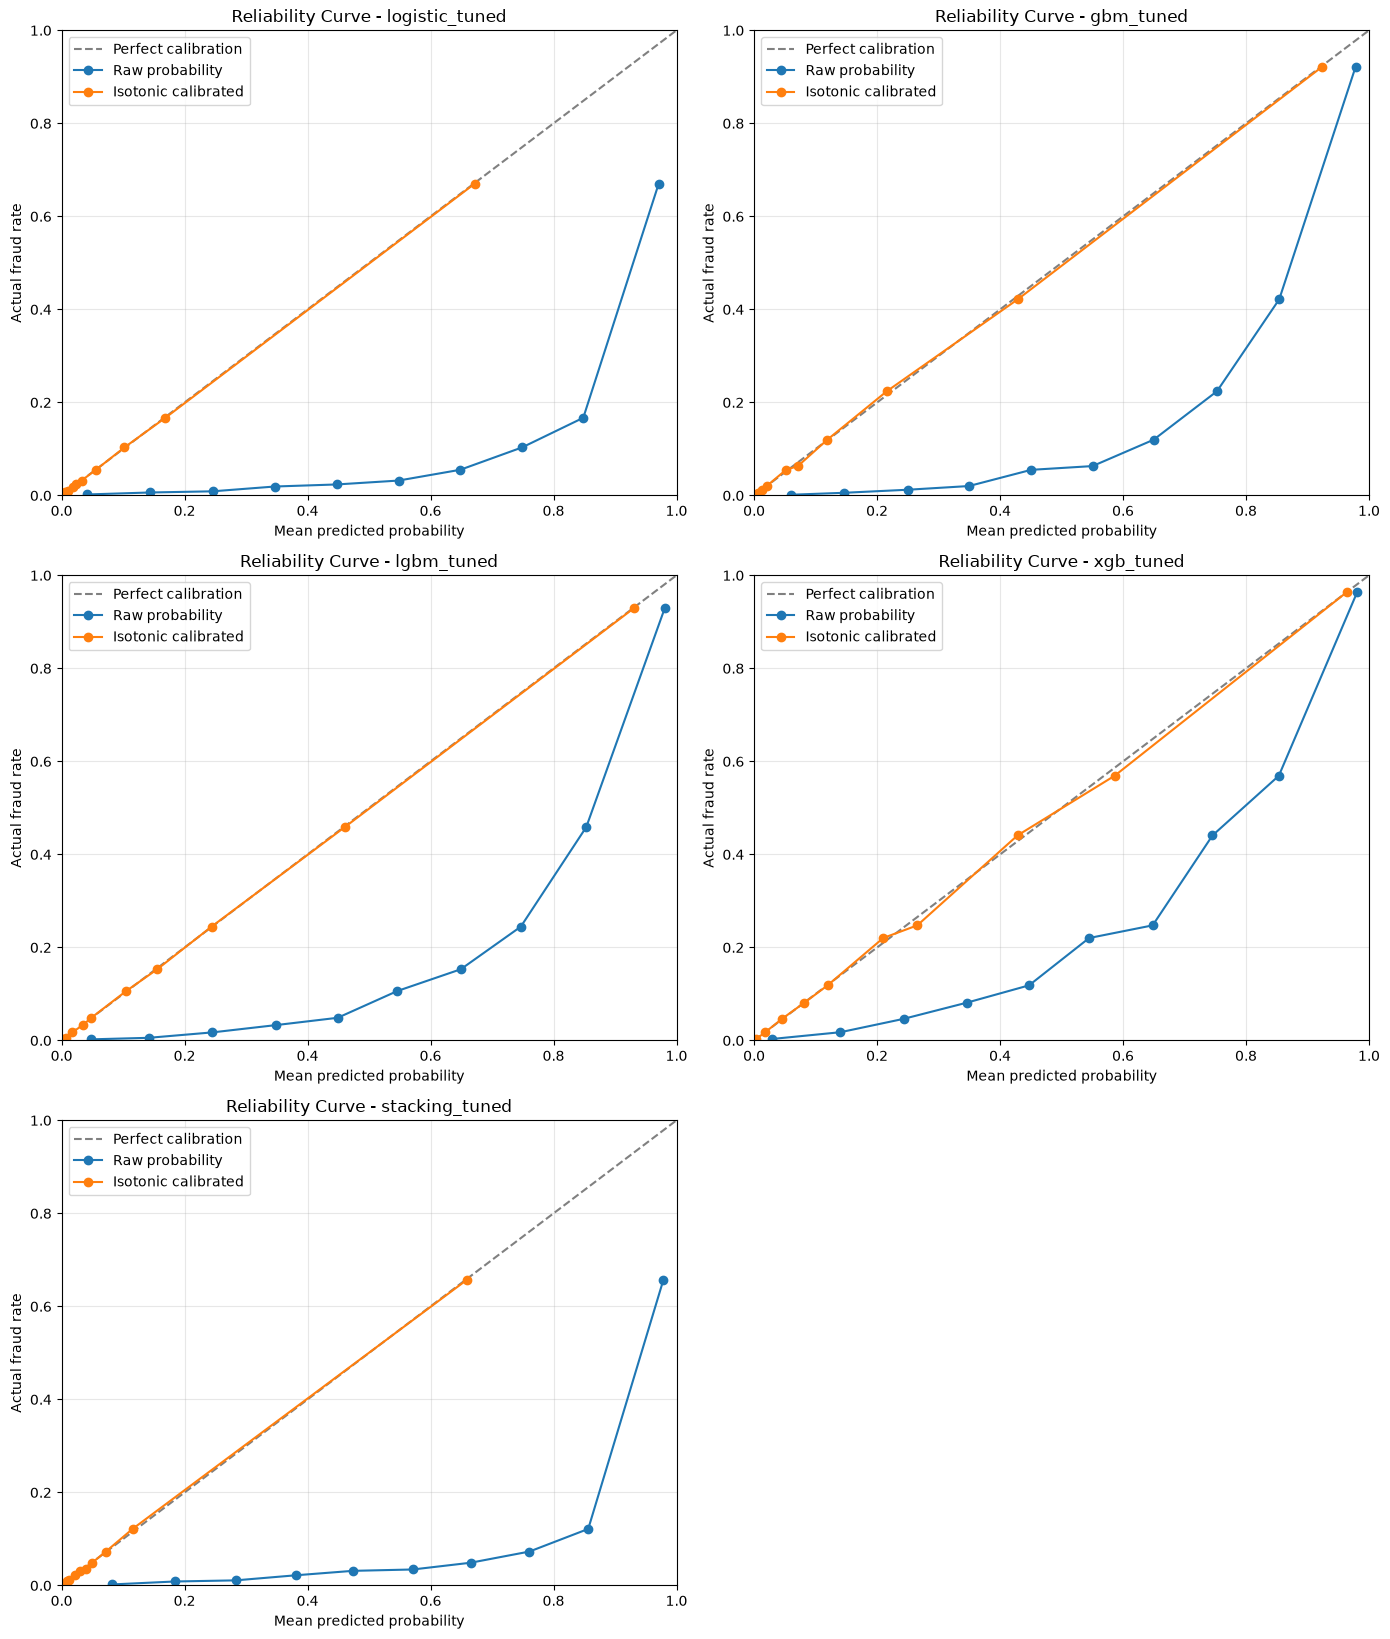

In [38]:
import math
import matplotlib.pyplot as plt

plot_models = list(calibration_artifacts)
n_models = len(plot_models)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5.5 * n_rows), squeeze=False)

for ax, model_name in zip(axes.ravel(), plot_models):
    plot_df = calibration_artifacts[model_name]["reliability_df"].dropna(
        subset=["mean_predicted_prob", "mean_calibrated_prob", "actual_fraud_rate"]
    )

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.plot(
        plot_df["mean_predicted_prob"],
        plot_df["actual_fraud_rate"],
        marker="o",
        label="Raw probability",
    )
    ax.plot(
        plot_df["mean_calibrated_prob"],
        plot_df["actual_fraud_rate"],
        marker="o",
        label="Isotonic calibrated",
    )

    ax.set_title(f"Reliability Curve - {model_name}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Actual fraud rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes.ravel()[len(plot_models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Final Fit On Full Train

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from tqdm import tqdm

def fit_final_stacking_ensemble(
    X,
    y,
    base_pipelines,
    meta_params=None,
    n_inner_splits=3,
    random_state=42,
):
    model_names = list(base_pipelines)
    meta_params = dict(meta_params or {})
    meta_params.setdefault("class_weight", "balanced")
    meta_params.setdefault("random_state", random_state)

    inner_oof = pd.DataFrame(0.0, index=X.index, columns=model_names)
    inner_folds = list(
        StratifiedKFold(n_splits=n_inner_splits, shuffle=True, random_state=random_state)
        .split(X, y)
    )

    for inner_train_idx, inner_val_idx in tqdm(
        inner_folds,
        desc="final stacking OOF",
        unit="fold",
    ):
        X_itrain, y_itrain = X.iloc[inner_train_idx], y.iloc[inner_train_idx]
        X_ival = X.iloc[inner_val_idx]

        for name, pipeline in base_pipelines.items():
            fold_pipeline = clone(pipeline).fit(X_itrain, y_itrain)
            inner_oof.loc[X_ival.index, name] = fold_pipeline.predict_proba(X_ival)[:, 1]

    meta_model = LogisticRegression(**meta_params)
    meta_model.fit(inner_oof, y)

    fitted_base_models = {}
    for name, pipeline in tqdm(
        base_pipelines.items(),
        desc="final stacking base fits",
        unit="model",
    ):
        fitted_base_models[name] = clone(pipeline).fit(X, y)

    return {
        "base_models": fitted_base_models,
        "meta_model": meta_model,
        "model_names": model_names,
        "meta_params": meta_params,
        "n_inner_splits": n_inner_splits,
    }

def predict_final_stacking_proba(final_stacking_model, X_new):
    base_preds = pd.DataFrame(index=X_new.index)
    for name in final_stacking_model["model_names"]:
        base_model = final_stacking_model["base_models"][name]
        base_preds[name] = base_model.predict_proba(X_new)[:, 1]
    return final_stacking_model["meta_model"].predict_proba(base_preds)[:, 1]

final_models = {}
final_model_specs = [
    ("logistic_tuned", "lr_pipeline_tuned"),
    ("gbm_tuned", "gbm_pipeline_tuned"),
    ("lgbm_tuned", "lgbm_pipeline_tuned"),
    ("xgb_tuned", "xgb_pipeline_tuned"),
]

for model_name, pipeline_var in final_model_specs:
    pipeline = globals().get(pipeline_var)
    if pipeline is None:
        print(f"Skip {model_name}: {pipeline_var} is not available")
        continue

    print(f"Fitting final {model_name} on full train...")
    final_models[model_name] = clone(pipeline).fit(X, y)

if "base_pipelines" in globals() and "best_stack_meta_params" in globals():
    final_stack_n_inner_splits = (
        stacking_study.best_params.get("n_inner_splits", 3)
        if "stacking_study" in globals()
        else 3
    )
    print("Fitting final stacking_tuned on full train...")
    final_stacking_model = fit_final_stacking_ensemble(
        X=X,
        y=y,
        base_pipelines=base_pipelines,
        meta_params=best_stack_meta_params,
        n_inner_splits=final_stack_n_inner_splits,
        random_state=42,
    )
    final_models["stacking_tuned"] = final_stacking_model
else:
    print("Skip stacking_tuned: base_pipelines or best_stack_meta_params is not available")

print("Final fitted models:", list(final_models))

Fitting final logistic_tuned on full train...


/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative sol

Fitting final gbm_tuned on full train...
Fitting final lgbm_tuned on full train...
Fitting final xgb_tuned on full train...
Fitting final stacking_tuned on full train...


final stacking OOF:   0%|          | 0/4 [00:00<?, ?fold/s]/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html

Final fitted models: ['logistic_tuned', 'gbm_tuned', 'lgbm_tuned', 'xgb_tuned', 'stacking_tuned']


## Holdout Scoring & Scorecard Generation

In [40]:
from src.scorecard.pdo import probability_to_pdo_score

if "final_models" not in globals() or not final_models:
    raise RuntimeError("final_models is missing or empty. Please run the 'Final Fit On Full Train' cell first.")

if "raw_data" not in globals() or "dts_holdout" not in raw_data:
    raise RuntimeError(
        "raw_data or raw_data['dts_holdout'] not loaded. Please run the data loading cells first."
    )

print("\nBuilding raw features for holdout set on the fly...")
X_holdout = build_raw_supervised_features(
    customer_df=raw_data["dts_holdout"],
    sim_events=raw_data["sim_events"],
    device_sessions=raw_data["device_sessions"],
    kyc_records=raw_data["kyc_records"],
    device_catalog=raw_data["device_catalog"],
)

if "CustomerID" not in X_holdout.columns:
    raise RuntimeError("X_holdout does not contain CustomerID.")

customer_ids = X_holdout["CustomerID"].to_numpy()
cols_to_drop = [c for c in ["FraudFlag", "FraudType", "Churn"] if c in X_holdout.columns]
X_holdout_input = X_holdout.drop(columns=cols_to_drop) if cols_to_drop else X_holdout.copy()

score_frames = []
for model_name in calibration_model_names:
    if model_name not in final_models:
        print(f"Skip {model_name}: final model is not available")
        continue
    if model_name not in calibration_artifacts:
        print(f"Skip {model_name}: calibrator is not available")
        continue

    print(f"Predicting and calibrating holdout P_fraud for {model_name}...")
    final_model = final_models[model_name]
    calibrator = calibration_artifacts[model_name]["calibrator"]

    if model_name == "stacking_tuned":
        if "predict_final_stacking_proba" not in globals():
            raise RuntimeError("predict_final_stacking_proba function not defined.")
        raw_p_fraud_model = predict_final_stacking_proba(final_model, X_holdout_input)
    else:
        raw_p_fraud_model = final_model.predict_proba(X_holdout_input)[:, 1]

    calibrated_p_fraud_model = calibrator.predict(raw_p_fraud_model)
    pdo_scores_model = probability_to_pdo_score(
        calibrated_p_fraud_model,
        base_score=BASE_SCORE,
        pdo=PDO,
    )

    score_frames.append(
        pd.DataFrame(
            {
                "CustomerID": customer_ids,
                "model_name": model_name,
                "raw_p_fraud": raw_p_fraud_model,
                "calibrated_p_fraud": calibrated_p_fraud_model,
                "pdo_score": np.round(pdo_scores_model).astype(int),
            }
        )
    )

if not score_frames:
    raise RuntimeError("No holdout scores were produced. Check final_models and calibration_artifacts.")

scores_df = pd.concat(score_frames, ignore_index=True)

# Backward-compatible selected-model view.
best_scores_df = scores_df[scores_df["model_name"] == best_model_name].copy()
if best_scores_df.empty:
    best_model_name = scores_df["model_name"].iloc[0]
    best_scores_df = scores_df[scores_df["model_name"] == best_model_name].copy()
best_model = final_models[best_model_name]

print("\nHoldout calibrated scores sample across all models:")
display(scores_df.head())

scores_path = OUTPUT_DIR / "supervised_holdout_calibrated_scores.csv"
scores_df.to_csv(scores_path, index=False)
print(f"File saved successfully: {scores_path}")



Building raw features for holdout set on the fly...
Predicting and calibrating holdout P_fraud for logistic_tuned...
Predicting and calibrating holdout P_fraud for gbm_tuned...
Predicting and calibrating holdout P_fraud for lgbm_tuned...
Predicting and calibrating holdout P_fraud for xgb_tuned...
Predicting and calibrating holdout P_fraud for stacking_tuned...

Holdout calibrated scores sample across all models:


,CustomerID,model_name,raw_p_fraud,calibrated_p_fraud,pdo_score
0,3000006,logistic_tuned,0.005084,0.000800,1000
1,3000018,logistic_tuned,0.001968,0.000000,1000
2,3000034,logistic_tuned,0.776699,0.100904,758
3,3000070,logistic_tuned,0.140368,0.005668,973
4,3000074,logistic_tuned,0.021803,0.001813,1000


File saved successfully: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/supervised_holdout_calibrated_scores.csv


## Explainability: Global SHAP And Local Case Studies


In [43]:
import importlib
import matplotlib.pyplot as plt

import src.explainability.shap_utils as shap_utils
import src.scorecard.reason_codes as reason_code_utils

importlib.reload(shap_utils)
importlib.reload(reason_code_utils)

from src.explainability.shap_utils import compute_shap_values, build_global_shap_importance
from src.scorecard.reason_codes import (
    generate_reason_codes_df,
    generate_reason_codes_for_models,
    select_explaining_pipeline,
)

TOP_N_REASONS = 5
REASON_CODE_MAX_ROWS = len(X_holdout_input)
GLOBAL_SHAP_TOP_N = 30
CASE_STUDY_ARCHETYPES = ["sim_swap_ato", "mule", "device_farm"]

ranked_model_names = calibration_model_summary_df["model_name"].tolist()
reason_model_names = [name for name in calibration_model_names if name in final_models]
primary_model_name = best_model_name if best_model_name in final_models else ranked_model_names[0]
primary_explaining_model_name, primary_explaining_pipeline = select_explaining_pipeline(
    model_name=primary_model_name,
    final_models=final_models,
    ranked_model_names=ranked_model_names,
)

if primary_explaining_pipeline is None:
    raise RuntimeError(f"No SHAP-compatible explaining model is available for {primary_model_name}.")

print(f"Primary score model: {primary_model_name}")
print(f"Primary SHAP explaining model: {primary_explaining_model_name}")
print(f"Reason code rows per model: {REASON_CODE_MAX_ROWS:,}")


Primary score model: stacking_tuned
Primary SHAP explaining model: lgbm_tuned
Reason code rows per model: 20,000


### Reason Codes


In [44]:
print(f"Generating holdout reason codes for {len(reason_model_names)} final models...")

reasons_df, reason_shap_artifacts = generate_reason_codes_for_models(
    model_names=reason_model_names,
    final_models=final_models,
    customer_ids=customer_ids,
    X_input=X_holdout_input,
    compute_shap_values_fn=compute_shap_values,
    ranked_model_names=ranked_model_names,
    top_n_reasons=TOP_N_REASONS,
    reason_code_max_rows=REASON_CODE_MAX_ROWS,
)

print("Holdout reason codes sample across models:")
display(reasons_df.head())

reasons_path = OUTPUT_DIR / "supervised_holdout_reason_codes.csv"
reasons_df.to_csv(reasons_path, index=False)
print(f"File saved successfully: {reasons_path}")


Generating holdout reason codes for 5 final models...


/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Holdout reason codes sample across models:


,CustomerID,model_name,explaining_model_name,reason_1,reason_2,reason_3,reason_4,reason_5
0,3000006,logistic_tuned,logistic_tuned,"face_match_score (val: -0.88, shap: +3.0190)","distinct_ip_count (val: -1.25, shap: -1.4841)","HandsetModels (val: 5.00, shap: -1.4469)","kyc_level_ord (val: -1.00, shap: -1.3713)","tac_imei_count_max (val: -0.19, shap: +1.3015)"
1,3000018,logistic_tuned,logistic_tuned,"kyc_level_ord (val: 0.00, shap: +2.6619)","face_match_score (val: 0.05, shap: -2.5131)","ServiceArea_woe (val: 1.82, shap: -2.1528)","tac_imei_count_max (val: -0.12, shap: +1.3494)","tac_customer_count_max (val: -0.10, shap: -1.3..."
2,3000034,logistic_tuned,logistic_tuned,"tac_customer_count_max (val: -6.80, shap: +4.5...","tac_imei_count_max (val: -8.82, shap: -4.5111)","kyc_level_ord (val: 0.00, shap: +2.6619)","shared_imei_flag (val: 1.00, shap: +2.2271)","face_match_score (val: -0.10, shap: -1.6460)"
3,3000070,logistic_tuned,logistic_tuned,"tac_customer_count_max (val: -9.75, shap: +7.1...","tac_imei_count_max (val: -12.55, shap: -7.0179)","face_match_score (val: 0.18, shap: -3.2701)","kyc_level_ord (val: 0.00, shap: +2.6619)","id_doc_match_score (val: 0.72, shap: -1.6722)"
4,3000074,logistic_tuned,logistic_tuned,"face_match_score (val: 0.21, shap: -3.4512)","kyc_level_ord (val: 0.00, shap: +2.6619)","tac_customer_count_max (val: 1.30, shap: -2.5457)","tac_imei_count_max (val: 1.48, shap: +2.4240)","id_doc_match_score (val: 0.68, shap: -1.6423)"


File saved successfully: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/supervised_holdout_reason_codes.csv


### Global SHAP


,rank,score_model_name,explaining_model_name,feature,mean_abs_shap,mean_shap
0,1,stacking_tuned,lgbm_tuned,distinct_ip_count,0.388451,-0.015028
1,2,stacking_tuned,lgbm_tuned,ServiceArea_woe,0.258642,-0.002559
2,3,stacking_tuned,lgbm_tuned,id_doc_match_score,0.240804,-0.042155
3,4,stacking_tuned,lgbm_tuned,home_cell_ratio,0.146695,-0.001898
4,5,stacking_tuned,lgbm_tuned,distinct_country_count,0.136749,-0.073761
5,6,stacking_tuned,lgbm_tuned,days_since_last_sim_swap,0.135995,0.008467
6,7,stacking_tuned,lgbm_tuned,face_match_score,0.131730,-0.011057
7,8,stacking_tuned,lgbm_tuned,max_customers_per_imei,0.121875,-0.002687
8,9,stacking_tuned,lgbm_tuned,night_session_ratio,0.117994,0.004446
9,10,stacking_tuned,lgbm_tuned,observed_device_days,0.092208,0.003961


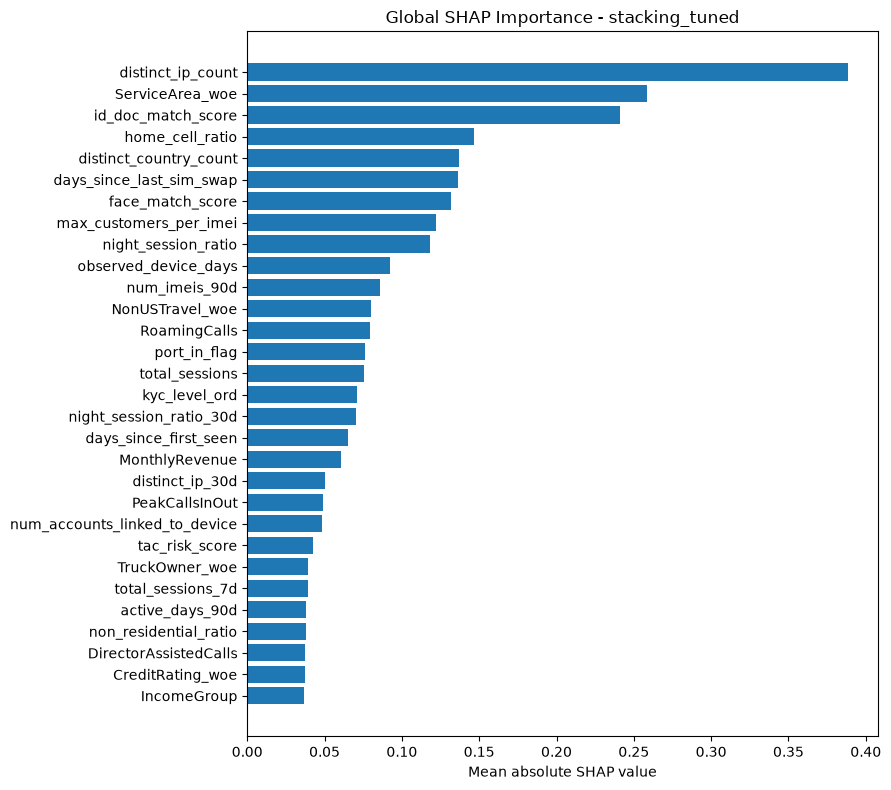

File saved successfully: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/supervised_global_shap_importance.csv


In [45]:
primary_artifact = reason_shap_artifacts.get(primary_model_name)

if primary_artifact and "shap_array" in primary_artifact:
    X_global_explain = primary_artifact["X_explain"]
    global_shap_array = primary_artifact["shap_array"]
else:
    X_global_explain = primary_explaining_pipeline._transform_features(X_holdout_input)
    global_shap_array = compute_shap_values(primary_explaining_pipeline, X_global_explain)

global_shap_importance_df = build_global_shap_importance(
    X_explain=X_global_explain,
    shap_array=global_shap_array,
    top_n=GLOBAL_SHAP_TOP_N,
)
global_shap_importance_df.insert(1, "score_model_name", primary_model_name)
global_shap_importance_df.insert(2, "explaining_model_name", primary_explaining_model_name)

global_shap_path = OUTPUT_DIR / "supervised_global_shap_importance.csv"
global_shap_importance_df.to_csv(global_shap_path, index=False)

display(global_shap_importance_df)

plot_df = global_shap_importance_df.sort_values("mean_abs_shap", ascending=True)
plt.figure(figsize=(9, 8))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.title(f"Global SHAP Importance - {primary_model_name}")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

print(f"File saved successfully: {global_shap_path}")


### Local Case Studies By Fraud Archetype


In [46]:
def predict_final_model_proba(model_name, model, X_input):
    if model_name == "stacking_tuned":
        return predict_final_stacking_proba(model, X_input)
    return model.predict_proba(X_input)[:, 1]

case_label_df = train_labels[["CustomerID", "FraudFlag", "FraudType"]].copy()
case_pool_df = X[["CustomerID"]].copy()
case_pool_df["_row_index"] = X.index
case_pool_df = case_pool_df.merge(case_label_df, on="CustomerID", how="left")

case_raw_p = predict_final_model_proba(primary_model_name, final_models[primary_model_name], X)
case_pool_df["raw_p_fraud"] = case_raw_p

if primary_model_name in calibration_artifacts:
    case_pool_df["calibrated_p_fraud"] = calibration_artifacts[primary_model_name]["calibrator"].predict(case_raw_p)
else:
    case_pool_df["calibrated_p_fraud"] = case_raw_p

available_archetypes = (
    case_pool_df.loc[case_pool_df["FraudFlag"].eq(1), "FraudType"]
    .dropna()
    .loc[lambda s: s.ne("none")]
    .value_counts()
)
case_study_archetypes = [a for a in CASE_STUDY_ARCHETYPES if a in available_archetypes.index]
for archetype in available_archetypes.index:
    if len(case_study_archetypes) >= 3:
        break
    if archetype not in case_study_archetypes:
        case_study_archetypes.append(archetype)

selected_cases = []
for archetype in case_study_archetypes[:3]:
    archetype_cases = (
        case_pool_df[case_pool_df["FraudType"].eq(archetype)]
        .sort_values("calibrated_p_fraud", ascending=False)
        .head(1)
    )
    selected_cases.append(archetype_cases)

case_study_base_df = pd.concat(selected_cases, ignore_index=True)
case_row_indices = case_study_base_df["_row_index"].tolist()
X_case_input = X.loc[case_row_indices]
X_case_explain = primary_explaining_pipeline._transform_features(X_case_input)
case_shap_array = compute_shap_values(primary_explaining_pipeline, X_case_explain)

case_reason_df = generate_reason_codes_df(
    customer_ids=case_study_base_df["CustomerID"].to_numpy(),
    X_explain=X_case_explain,
    shap_array=case_shap_array,
    top_n_reasons=TOP_N_REASONS,
    reason_code_max_rows=None,
)

case_study_df = (
    case_study_base_df.drop(columns=["_row_index"])
    .assign(
        score_model_name=primary_model_name,
        explaining_model_name=primary_explaining_model_name,
    )
    .merge(case_reason_df, on="CustomerID", how="left")
)

case_study_path = OUTPUT_DIR / "supervised_local_shap_case_studies.csv"
case_study_df.to_csv(case_study_path, index=False)

display(case_study_df)
print(f"File saved successfully: {case_study_path}")


/Users/duongminhquan/Documents/VDT_VDS_2026/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,CustomerID,FraudFlag,FraudType,raw_p_fraud,calibrated_p_fraud,score_model_name,explaining_model_name,reason_1,reason_2,reason_3,reason_4,reason_5
0,3089538,1,sim_swap_ato,0.996586,0.98951,stacking_tuned,lgbm_tuned,"days_since_last_sim_swap (val: -1.03, shap: +2...","distinct_ip_count (val: 2.00, shap: +1.9731)","distinct_country_count (val: 1.00, shap: +1.1181)","sim_swap_count_total (val: 3.00, shap: +1.0683)","NonUSTravel_woe (val: 0.01, shap: +0.7502)"
1,3000462,1,mule,0.996537,0.98951,stacking_tuned,lgbm_tuned,"max_customers_per_imei (val: 3.00, shap: +3.0667)","home_cell_ratio (val: -2.62, shap: +1.9884)","distinct_ip_count (val: 2.00, shap: +1.3809)","num_accounts_linked_to_device (val: 3.00, shap...","tac_risk_score (val: 1.00, shap: +0.5124)"
2,3196754,1,device_farm,0.996592,0.98951,stacking_tuned,lgbm_tuned,"max_customers_per_imei (val: 6.00, shap: +2.9098)","tac_risk_score (val: 2.00, shap: +1.9856)","non_residential_ratio (val: 0.76, shap: +1.9146)","id_doc_match_score (val: -9.80, shap: +0.9115)","num_accounts_linked_to_device (val: 6.00, shap..."


File saved successfully: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/supervised_local_shap_case_studies.csv


## Submission Files By Model


In [47]:
SUBMIT_DIR = OUTPUT_DIR / "submit"
SUBMIT_DIR.mkdir(parents=True, exist_ok=True)

scores_source_path = OUTPUT_DIR / "supervised_holdout_calibrated_scores.csv"
if "scores_df" in globals() and not scores_df.empty:
    submission_scores_df = scores_df.copy()
elif scores_source_path.exists():
    submission_scores_df = pd.read_csv(scores_source_path)
else:
    raise RuntimeError(
        "scores_df is missing and supervised_holdout_calibrated_scores.csv does not exist. "
        "Run the holdout scoring cell first."
    )

required_score_cols = {"CustomerID", "model_name", "calibrated_p_fraud", "pdo_score"}
missing_score_cols = required_score_cols - set(submission_scores_df.columns)
if missing_score_cols:
    raise RuntimeError(f"Missing columns in calibrated scores: {sorted(missing_score_cols)}")

submit_name_map = {
    "logistic_tuned": "logistic.csv",
    "gbm_tuned": "gbm.csv",
    "lgbm_tuned": "lgbm.csv",
    "xgb_tuned": "xgb.csv",
    "stacking_tuned": "stacking.csv",
}

submission_paths = []
for model_name, model_scores_df in submission_scores_df.groupby("model_name", sort=False):
    submit_df = (
        model_scores_df[["CustomerID", "calibrated_p_fraud", "pdo_score"]]
        .rename(columns={"calibrated_p_fraud": "P_fraud", "pdo_score": "DTS"})
        .sort_values("CustomerID")
        .reset_index(drop=True)
    )

    assert submit_df["CustomerID"].is_unique, f"Duplicate CustomerID in {model_name} submission"
    assert submit_df["P_fraud"].between(0, 1).all(), f"P_fraud out of range in {model_name} submission"
    assert submit_df["DTS"].between(0, 1000).all(), f"DTS out of range in {model_name} submission"

    output_name = submit_name_map.get(model_name, f"{model_name}.csv")
    output_path = SUBMIT_DIR / output_name
    submit_df.to_csv(output_path, index=False)
    submission_paths.append(
        {
            "model_name": model_name,
            "rows": len(submit_df),
            "path": str(output_path),
        }
    )

submission_manifest_df = pd.DataFrame(submission_paths)
manifest_path = SUBMIT_DIR / "manifest.csv"
submission_manifest_df.to_csv(manifest_path, index=False)

display(submission_manifest_df)
print(f"Submission files saved under: {SUBMIT_DIR}")
print(f"Manifest saved successfully: {manifest_path}")


,model_name,rows,path
0,logistic_tuned,20000,/Users/duongminhquan/Documents/VDT_VDS_2026/ou...
1,gbm_tuned,20000,/Users/duongminhquan/Documents/VDT_VDS_2026/ou...
2,lgbm_tuned,20000,/Users/duongminhquan/Documents/VDT_VDS_2026/ou...
3,xgb_tuned,20000,/Users/duongminhquan/Documents/VDT_VDS_2026/ou...
4,stacking_tuned,20000,/Users/duongminhquan/Documents/VDT_VDS_2026/ou...


Submission files saved under: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/submit
Manifest saved successfully: /Users/duongminhquan/Documents/VDT_VDS_2026/outputs/supervised/submit/manifest.csv
